In [1]:

RANDOM_STATE = 42
OUT_DIR = "runs"
RUN_NAME = "ethereum"

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.base import clone
from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings("ignore")




In [3]:

DATA_PATH = r"D:\elliptic\Ethereum-Fraud-Detection-Dataset\transaction_dataset.csv"

df = pd.read_csv(DATA_PATH, index_col=0)
print("Raw shape:", df.shape)
display(df.head())


df = df.iloc[:, 2:]



Raw shape: (9841, 50)


,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [4]:

categories = df.select_dtypes('O').columns
print("The original object-type (categorical) columns.:")
print(categories.tolist())


if len(categories) > 0:
    df.drop(columns=categories, inplace=True)
    print("\nObject-type columns have been dropped.. Shape:", df.shape)


df = df.apply(pd.to_numeric, errors="coerce")  
df.fillna(df.median(), inplace=True)

print("\nRemaining missing values per column after median imputation.:")
print(df.isna().sum().sort_values(ascending=False).head())


no_var = df.var() == 0
zero_var_cols = df.var()[no_var].index.tolist()
print("\nColumns with zero variance:")
print(zero_var_cols)

if zero_var_cols:
    df.drop(columns=zero_var_cols, inplace=True)
    print("Shape after dropping zero-variance columns:", df.shape)


The original object-type (categorical) columns.:
[' ERC20 most sent token type', ' ERC20_most_rec_token_type']

Object-type columns have been dropped.. Shape: (9841, 46)

Remaining missing values per column after median imputation.:
FLAG                                       0
Avg min between sent tnx                   0
Avg min between received tnx               0
Time Diff between first and last (Mins)    0
Sent tnx                                   0
dtype: int64

Columns with zero variance:
[' ERC20 avg time between sent tnx', ' ERC20 avg time between rec tnx', ' ERC20 avg time between rec 2 tnx', ' ERC20 avg time between contract tnx', ' ERC20 min val sent contract', ' ERC20 max val sent contract', ' ERC20 avg val sent contract']
Shape after dropping zero-variance columns: (9841, 39)


In [5]:


drop_cols = ['min value sent to contract', ' ERC20 uniq sent addr.1']

existing_drop_cols = [c for c in drop_cols if c in df.columns]
if existing_drop_cols:
    df.drop(columns=existing_drop_cols, inplace=True)
    print("Dropped the column(s):", existing_drop_cols)


print("Final shape of the df:", df.shape)
display(df.head())


Dropped the column(s): ['min value sent to contract', ' ERC20 uniq sent addr.1']
Final shape of the df: (9841, 37)


,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,...,ERC20 uniq rec addr,ERC20 uniq rec contract addr,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 uniq sent token name,ERC20 uniq rec token name
0,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,...,54.0,58.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,39.0,57.0
1,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,...,5.0,7.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,1.0,7.0
2,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,...,7.0,8.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,8.0
3,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,...,11.0,11.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,1.0,11.0
4,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,...,23.0,27.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,6.0,27.0


In [6]:
df.columns

Index(['FLAG', 'Avg min between sent tnx', 'Avg min between received tnx',
       'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'max val sent to contract', 'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received',
       'total ether sent contracts', 'total ether balance',
       ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq rec contract addr', ' ERC20 min val rec',
       ' ERC20 max val rec', ' ERC20 avg val rec', ' ERC20 min val sent',
       ' ERC20 max val sent', ' ERC20 avg val sent',
       

In [7]:
df['total transactions'] =  df ['total transactions (including tnx to create contract']
df['Time Diff (last-first)'] =  df ['Time Diff between first and last (Mins)']
df['UniqueRecvAddr'] =  df ['Unique Received From Addresses']
df=df.drop(columns=['total transactions (including tnx to create contract', 'Time Diff between first and last (Mins)','Unique Received From Addresses'])

In [8]:
df.columns

Index(['FLAG', 'Avg min between sent tnx', 'Avg min between received tnx',
       'Sent tnx', 'Received Tnx', 'Number of Created Contracts',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'max val sent to contract', 'avg value sent to contract',
       'total Ether sent', 'total ether received',
       'total ether sent contracts', 'total ether balance',
       ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq rec contract addr', ' ERC20 min val rec',
       ' ERC20 max val rec', ' ERC20 avg val rec', ' ERC20 min val sent',
       ' ERC20 max val sent', ' ERC20 avg val sent',
       ' ERC20 uniq sent token name', ' ERC20 uniq rec token name',
       'total transactions', 'Time Diff (last-first)', 'UniqueRecvAddr'],
      dtype=

In [9]:


y = df.iloc[:, 0].astype(int)  
X = df.iloc[:, 1:]
print("X shape:", X.shape, "y shape:", y.shape)

print("\nLabel distribution for the entire dataset.:")
print(y.value_counts())


X shape: (9841, 36) y shape: (9841,)

Label distribution for the entire dataset.:
FLAG
0    7662
1    2179
Name: count, dtype: int64


In [10]:


TEST_SIZE = 0.15
VAL_SIZE  = 0.15


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

val_ratio_in_temp = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio_in_temp,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

def show_stats(name, yy):
    yy = np.asarray(yy)
    counts = np.bincount(yy)
    n0 = counts[0] if len(counts) > 0 else 0
    n1 = counts[1] if len(counts) > 1 else 0
    ratio = n1 / (n0 + n1) if (n0 + n1) > 0 else 0
    print(f"{name:5s}: 0 = {n0:7d}, 1 = {n1:5d}, scam_ratio = {ratio:.6f}")

print("Shapes:")
print("  Train:", X_train.shape, y_train.shape)
print("  Val  :", X_val.shape,   y_val.shape)
print("  Test :", X_test.shape,  y_test.shape)

print("\n=== Label distribution after splitting ===")
show_stats("ALL",   y)
show_stats("Train", y_train)
show_stats("Val",   y_val)
show_stats("Test",  y_test)


Shapes:
  Train: (6888, 36) (6888,)
  Val  : (1476, 36) (1476,)
  Test : (1477, 36) (1477,)

=== Label distribution after splitting ===
ALL  : 0 =    7662, 1 =  2179, scam_ratio = 0.221421
Train: 0 =    5363, 1 =  1525, scam_ratio = 0.221400
Val  : 0 =    1149, 1 =   327, scam_ratio = 0.221545
Test : 0 =    1150, 1 =   327, scam_ratio = 0.221395


In [11]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

feature_cols = X.columns.tolist()
print("Number of features:", len(feature_cols))


Number of features: 36


In [12]:


def sample_param(dist, rng):

    if hasattr(dist, "rvs"):
        return dist.rvs(random_state=rng)
    dist = list(dist)
    return dist[rng.randint(0, len(dist))]

def random_search_single_model(
    name,
    base_estimator,
    param_dist,
    X_train, y_train,
    X_val,   y_val,
    n_iter=30,
    random_state=42,
):
    rng = np.random.RandomState(random_state)
    best_f1_macro = -1.0
    best_params = None

    for i in range(n_iter):
        params = {}
        for k, dist in param_dist.items():
            params[k] = sample_param(dist, rng)

        model = clone(base_estimator)
        model.set_params(**params)
        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)


        f1_macro = f1_score(y_val, y_val_pred, average="macro")

        print(f"[{name}] iter {i+1:02d}/{n_iter:02d} - F1_macro(val) = {f1_macro:.6f}")

        if f1_macro > best_f1_macro:
            best_f1_macro = f1_macro
            best_params = params

    print(f"\n>>> {name} - BEST F1_macro(val) = {best_f1_macro:.6f}")
    print("Best params:", best_params)

    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])

    best_model = clone(base_estimator)
    best_model.set_params(**best_params)
    best_model.fit(X_train_full, y_train_full)

    return best_model


In [13]:

rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_param_dist = {
    "n_estimators": randint(200, 600),
    "max_depth": randint(3, 30),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

best_rf = random_search_single_model(
    "RandomForest",
    rf_base,
    rf_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30,
    random_state=RANDOM_STATE
)


[RandomForest] iter 01/30 - F1_macro(val) = 0.960378
[RandomForest] iter 02/30 - F1_macro(val) = 0.971673
[RandomForest] iter 03/30 - F1_macro(val) = 0.970907
[RandomForest] iter 04/30 - F1_macro(val) = 0.966968
[RandomForest] iter 05/30 - F1_macro(val) = 0.876136
[RandomForest] iter 06/30 - F1_macro(val) = 0.973684
[RandomForest] iter 07/30 - F1_macro(val) = 0.968830
[RandomForest] iter 08/30 - F1_macro(val) = 0.957790
[RandomForest] iter 09/30 - F1_macro(val) = 0.976273
[RandomForest] iter 10/30 - F1_macro(val) = 0.959624
[RandomForest] iter 11/30 - F1_macro(val) = 0.952524
[RandomForest] iter 12/30 - F1_macro(val) = 0.962469
[RandomForest] iter 13/30 - F1_macro(val) = 0.971943
[RandomForest] iter 14/30 - F1_macro(val) = 0.955871
[RandomForest] iter 15/30 - F1_macro(val) = 0.965774
[RandomForest] iter 16/30 - F1_macro(val) = 0.896209
[RandomForest] iter 17/30 - F1_macro(val) = 0.951226
[RandomForest] iter 18/30 - F1_macro(val) = 0.972501
[RandomForest] iter 19/30 - F1_macro(val) = 0.

In [14]:

xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    tree_method="hist",      
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_param_dist = {
    "n_estimators": randint(300, 800),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),        
    "colsample_bytree": uniform(0.6, 0.4),  
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "reg_lambda": uniform(0, 5),
    "objective": ["binary:logistic"],      
    "eval_metric": ["logloss", "aucpr"],    
}


best_xgb = random_search_single_model(
    "XGBoost",
    xgb_base,
    xgb_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30,
    random_state=RANDOM_STATE
)


[XGBoost] iter 01/30 - F1_macro(val) = 0.981278
[XGBoost] iter 02/30 - F1_macro(val) = 0.980228
[XGBoost] iter 03/30 - F1_macro(val) = 0.977287
[XGBoost] iter 04/30 - F1_macro(val) = 0.979216
[XGBoost] iter 05/30 - F1_macro(val) = 0.975202
[XGBoost] iter 06/30 - F1_macro(val) = 0.973218
[XGBoost] iter 07/30 - F1_macro(val) = 0.979216
[XGBoost] iter 08/30 - F1_macro(val) = 0.972257
[XGBoost] iter 09/30 - F1_macro(val) = 0.980271
[XGBoost] iter 10/30 - F1_macro(val) = 0.983212
[XGBoost] iter 11/30 - F1_macro(val) = 0.977186
[XGBoost] iter 12/30 - F1_macro(val) = 0.970275
[XGBoost] iter 13/30 - F1_macro(val) = 0.979170
[XGBoost] iter 14/30 - F1_macro(val) = 0.981320
[XGBoost] iter 15/30 - F1_macro(val) = 0.976273
[XGBoost] iter 16/30 - F1_macro(val) = 0.975257
[XGBoost] iter 17/30 - F1_macro(val) = 0.979262
[XGBoost] iter 18/30 - F1_macro(val) = 0.977337
[XGBoost] iter 19/30 - F1_macro(val) = 0.976220
[XGBoost] iter 20/30 - F1_macro(val) = 0.980315
[XGBoost] iter 21/30 - F1_macro(val) = 0

In [15]:
# 8.3 LightGBM
lgbm_base = LGBMClassifier(
    random_state=RANDOM_STATE,
    objective="binary",
    n_jobs=-1
)

lgbm_param_dist = {
    "n_estimators": randint(300, 800),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),         
    "colsample_bytree": uniform(0.6, 0.4),  
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "reg_lambda": uniform(0, 5),
    "objective": ["binary"],       
    "eval_metric": ["logloss", "aucpr"],    
}

best_lgbm = random_search_single_model(
    "LightGBM",
    lgbm_base,
    lgbm_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30,
    random_state=RANDOM_STATE
)


[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Number of positive: 1525, number of negative: 5363
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000901 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6651
[LightGBM] [Info] Number of data points in the train set: 6888, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221400 -> initscore=-1.257529
[LightGBM] [Info] Start training from score -1.257529
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

In [16]:

from itertools import combinations
from sklearn.metrics import roc_auc_score

base_models = {
    "RF": best_rf,
    "XGB": best_xgb,
    "LGBM": best_lgbm
}

def _proba_pos(model, X):
    proba = model.predict_proba(X)
    if proba.ndim == 2 and proba.shape[1] >= 2:
        return proba[:, 1]
    return proba.ravel()

def ensemble_predict(models_dict, X, voting="soft", threshold=0.5):
    models = list(models_dict.values())

    probas = np.vstack([_proba_pos(m, X) for m in models]) 
    proba_mean = probas.mean(axis=0)

    if voting == "soft":
        y_pred = (proba_mean >= threshold).astype(int)
        return y_pred, proba_mean

    if voting == "hard":
        preds = np.vstack([m.predict(X) for m in models]).astype(int)
        votes = preds.sum(axis=0)
        half = len(models) / 2

        y_pred = (votes > half).astype(int)


        tie_mask = (votes == half)
        if np.any(tie_mask):
            y_pred[tie_mask] = (proba_mean[tie_mask] >= threshold).astype(int)

        return y_pred, proba_mean

    raise ValueError("voting phải là 'hard' hoặc 'soft'")

def eval_binary(y_true, y_pred, y_score=None):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)
    out["f1_binary"] = f1_score(y_true, y_pred)
    out["f1_micro"]  = f1_score(y_true, y_pred, average="micro")
    out["f1_macro"]  = f1_score(y_true, y_pred, average="macro")
    if y_score is not None:
        try:
            out["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            out["roc_auc"] = np.nan
    return out



def _fmt(x):
    return f"{x:.6f}" if (x is not None and np.isfinite(x)) else "nan"

results = []


combos = list(combinations(base_models.keys(), 2)) + [tuple(base_models.keys())]

for combo in combos:
    combo_models = {k: base_models[k] for k in combo}
    combo_name = "+".join(combo)

    for voting in ["hard", "soft"]:
        y_pred, y_score = ensemble_predict(combo_models, X_test_scaled, voting=voting, threshold=0.5)
        m = eval_binary(y_test, y_pred, y_score)
        
        results.append({"ensemble": combo_name, "voting": voting, **m})

        print(f"\n===== Ensemble [{combo_name}] | {voting.upper()} vote =====")
        print(classification_report(y_test, y_pred, digits=6))
        print("Accuracy:", _fmt(m["accuracy"]))
        print("F1 (binary, pos_label=1):", _fmt(m["f1_binary"]))
        print("F1 micro:", _fmt(m["f1_micro"]))
        print("F1 macro:", _fmt(m["f1_macro"]))
        print("ROC-AUC:", _fmt(m.get("roc_auc", np.nan)))
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(
    by=["f1_binary", "roc_auc", "accuracy"],
    ascending=False
)
display(results_df)



===== Ensemble [RF+XGB] | HARD vote =====
              precision    recall  f1-score   support

           0   0.985320  0.992174  0.988735      1150
           1   0.971787  0.948012  0.959752       327

    accuracy                       0.982397      1477
   macro avg   0.978553  0.970093  0.974244      1477
weighted avg   0.982323  0.982397  0.982318      1477

Accuracy: 0.982397
F1 (binary, pos_label=1): 0.959752
F1 micro: 0.982397
F1 macro: 0.974244
ROC-AUC: 0.997657
Confusion matrix:
[[1141    9]
 [  17  310]]

===== Ensemble [RF+XGB] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.985320  0.992174  0.988735      1150
           1   0.971787  0.948012  0.959752       327

    accuracy                       0.982397      1477
   macro avg   0.978553  0.970093  0.974244      1477
weighted avg   0.982323  0.982397  0.982318      1477

Accuracy: 0.982397
F1 (binary, pos_label=1): 0.959752
F1 micro: 0.982397
F1 macro: 0.974244
ROC-AUC: 0.99

,ensemble,voting,accuracy,f1_binary,f1_micro,f1_macro,roc_auc
4,XGB+LGBM,hard,0.984428,0.964119,0.984428,0.977087,0.998093
5,XGB+LGBM,soft,0.984428,0.964119,0.984428,0.977087,0.998093
6,RF+XGB+LGBM,hard,0.983751,0.962733,0.983751,0.976172,0.997859
7,RF+XGB+LGBM,soft,0.983751,0.962733,0.983751,0.976172,0.997859
2,RF+LGBM,hard,0.983751,0.962617,0.983751,0.976118,0.997676
3,RF+LGBM,soft,0.983751,0.962617,0.983751,0.976118,0.997676
0,RF+XGB,hard,0.982397,0.959752,0.982397,0.974244,0.997657
1,RF+XGB,soft,0.982397,0.959752,0.982397,0.974244,0.997657


In [17]:


models = {
    "RF": best_rf,
    "XGB": best_xgb,
    "LightGBM": best_lgbm
}

def _score_pos(model, X):

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1]
        return proba.ravel()
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None

def _fmt(x):
    return f"{x:.6f}" if (x is not None and np.isfinite(x)) else "nan"

for name, model in models.items():
    print(f"\n===== {name} on TEST =====")
    y_pred_test = model.predict(X_test_scaled)

    acc      = accuracy_score(y_test, y_pred_test)
    f1_scam  = f1_score(y_test, y_pred_test)             
    f1_micro = f1_score(y_test, y_pred_test, average="micro")
    f1_macro = f1_score(y_test, y_pred_test, average="macro")

    y_score = _score_pos(model, X_test_scaled)
    if y_score is not None and len(np.unique(y_test)) >= 2:
        try:
            auc = roc_auc_score(y_test, y_score)
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    print("Accuracy:", _fmt(acc))
    print("F1 (scam - binary, pos_label=1):", _fmt(f1_scam))
    print("F1 micro:", _fmt(f1_micro))
    print("F1 macro:", _fmt(f1_macro))
    print("ROC-AUC:", _fmt(auc))

    print("\nclassification_report:")
    print(classification_report(y_test, y_pred_test, digits=6))

    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred_test))



===== RF on TEST =====
Accuracy: 0.979012
F1 (scam - binary, pos_label=1): 0.952381
F1 micro: 0.979012
F1 macro: 0.969460
ROC-AUC: 0.996657

classification_report:
              precision    recall  f1-score   support

           0   0.985256  0.987826  0.986539      1150
           1   0.956790  0.948012  0.952381       327

    accuracy                       0.979012      1477
   macro avg   0.971023  0.967919  0.969460      1477
weighted avg   0.978954  0.979012  0.978977      1477

Confusion matrix:
[[1136   14]
 [  17  310]]

===== XGB on TEST =====
Accuracy: 0.983074
F1 (scam - binary, pos_label=1): 0.961360
F1 micro: 0.983074
F1 macro: 0.975262
ROC-AUC: 0.997984

classification_report:
              precision    recall  f1-score   support

           0   0.986171  0.992174  0.989163      1150
           1   0.971875  0.951070  0.961360       327

    accuracy                       0.983074      1477
   macro avg   0.979023  0.971622  0.975262      1477
weighted avg   0.983006  

 14%|===                 | 408/2954 [00:12<01:14]       

Background SHAP size: (6888, 36)
Explain SHAP size   : (1477, 36)

================ SHAP for RF (Ethereum) ================


100%|===================| 2945/2954 [01:16<00:00]        

  sv_pos.shape = (1477, 36) | ndim = 2

================ SHAP for XGB (Ethereum) ================
  sv_pos.shape = (1477, 36) | ndim = 2

================ SHAP for LightGBM (Ethereum) ================


 98%|===================| 1454/1477 [00:13<00:00]        

  sv_pos.shape = (1477, 36) | ndim = 2


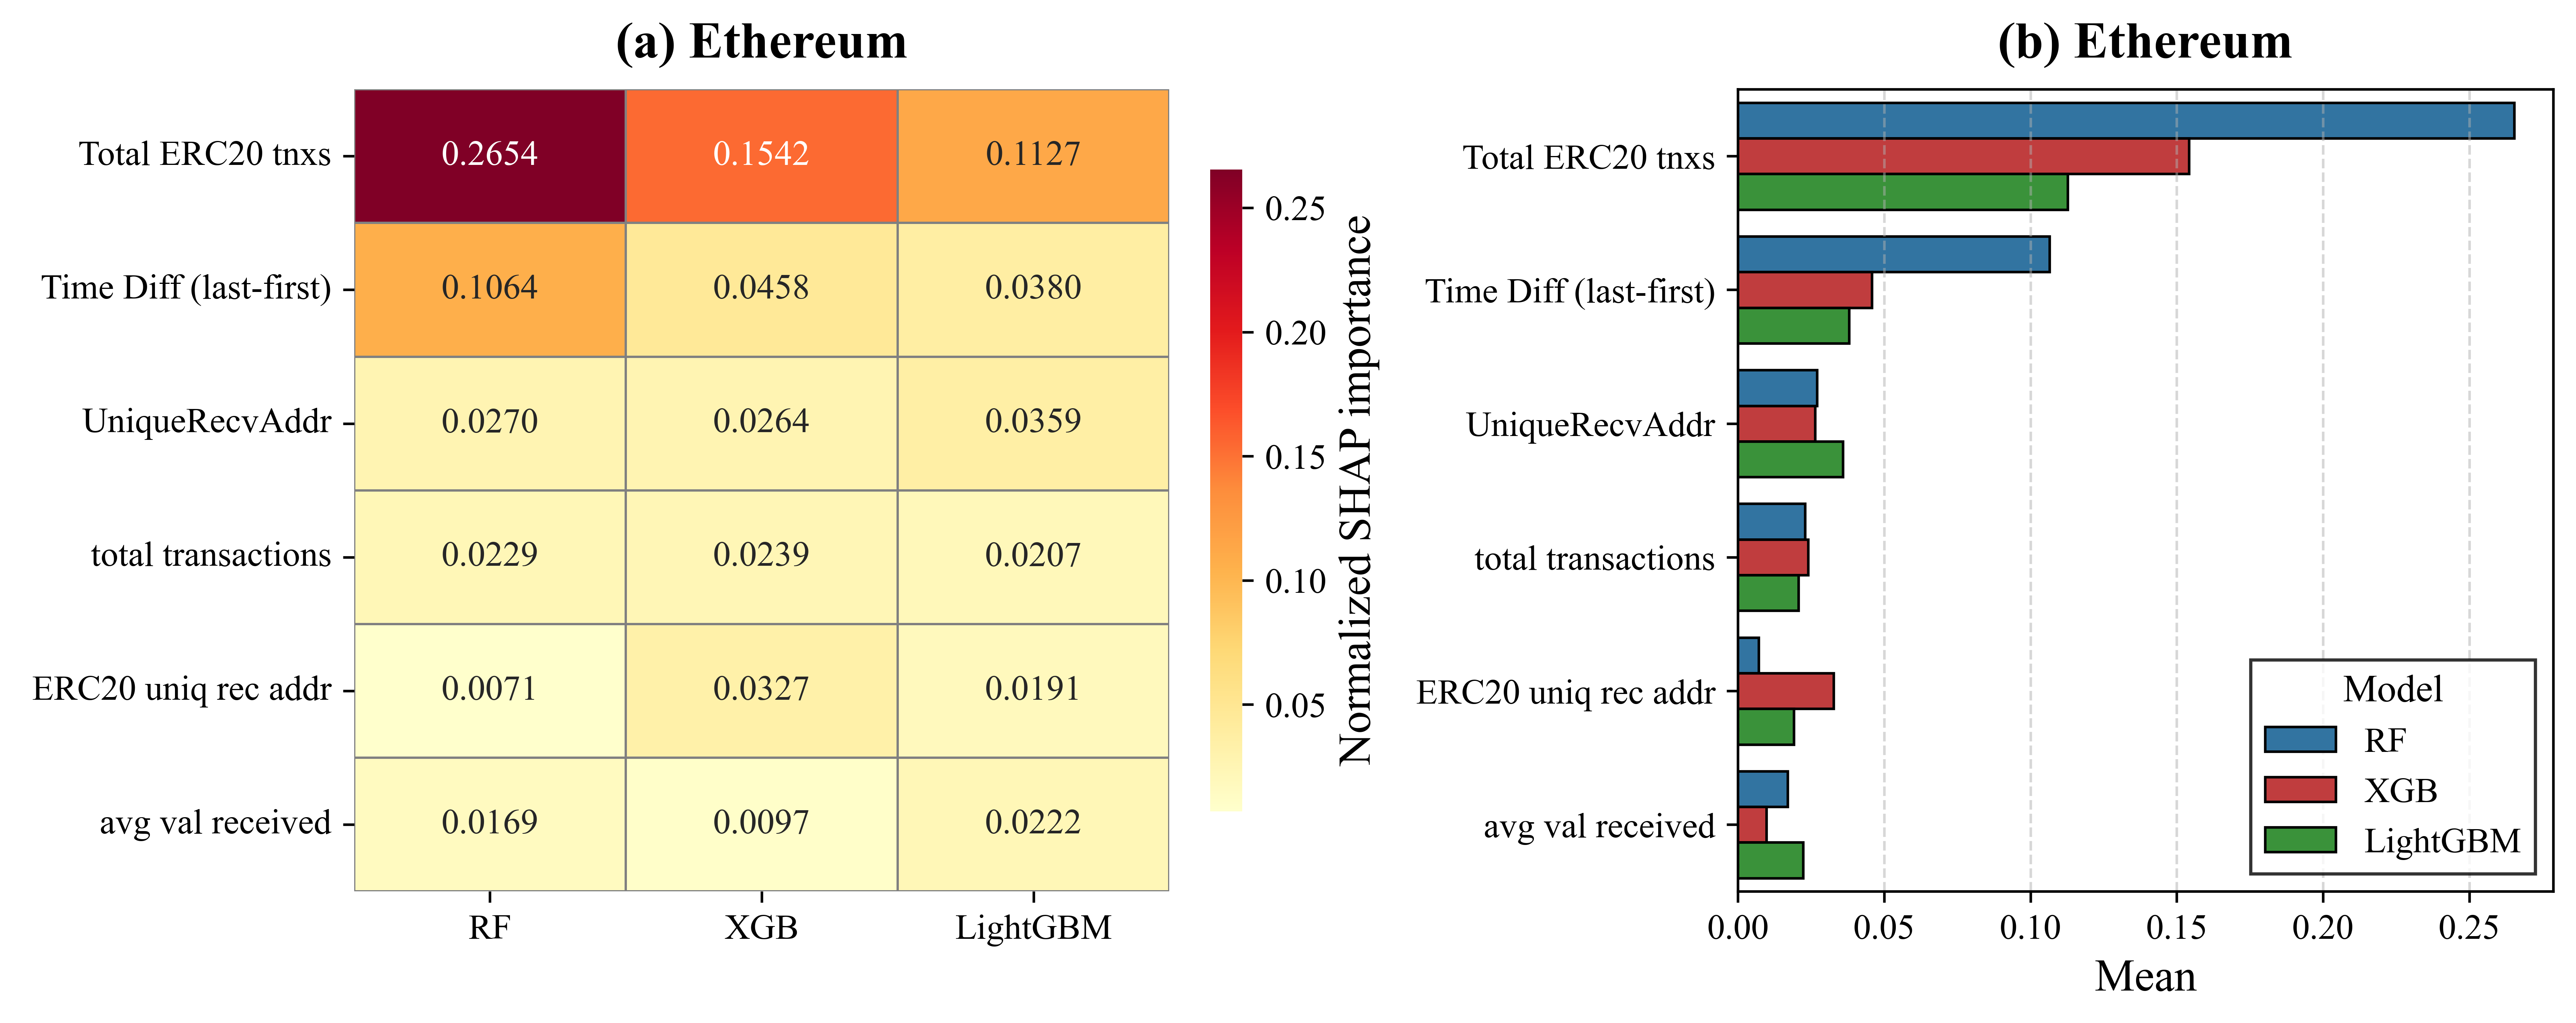

In [18]:

import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

shap.initjs()


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 18


n_background =  X_train_scaled.shape[0]
n_explain    = X_test_scaled.shape[0]

X_background = X_train_scaled[:n_background]
X_explain    = X_test_scaled[:n_explain]

print(f"Background SHAP size: {X_background.shape}")
print(f"Explain SHAP size   : {X_explain.shape}")

mean_abs_dict = {}   

for name, model in models.items():
    print(f"\n================ SHAP for {name} (Ethereum) ================")

    expl = shap.TreeExplainer(
        model,
        data=X_background,
        feature_perturbation="interventional",
        model_output="probability"    
    )

    sv = expl.shap_values(
        X_explain,
        check_additivity=False
    )


    if isinstance(sv, list):
        if hasattr(model, "classes_"):
            cls_idx = int(np.where(model.classes_ == 1)[0][0])
        else:
            cls_idx = 1
        sv_pos = np.array(sv[cls_idx])

    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        if hasattr(model, "classes_"):
            cls_idx = int(np.where(model.classes_ == 1)[0][0])
        else:
            cls_idx = sv.shape[2] - 1
        sv_pos = np.array(sv[:, :, cls_idx])

    else:
        sv_pos = np.array(sv)

    assert sv_pos.ndim == 2, f"sv_pos is not 2D in model {name} (shape={sv_pos.shape})"
    print("  sv_pos.shape =", sv_pos.shape, "| ndim =", sv_pos.ndim)


    mean_abs = np.mean(np.abs(sv_pos), axis=0)   
    mean_abs_dict[name] = mean_abs


df_mean = pd.DataFrame(mean_abs_dict, index=feature_cols)

top_n = 6 if len(feature_cols) >= 10 else len(feature_cols)

df_mean['avg'] = df_mean.mean(axis=1)
df_mean = df_mean.sort_values('avg', ascending=False)
df_top = df_mean.head(top_n).drop(columns='avg') 





plt.close('all')
fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4.3),  
    dpi=600,
    constrained_layout=True
)
ax0, ax1 = axes


sns.heatmap(
    df_top,
    annot=True,
    fmt=".4f",              
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Normalized SHAP importance", "shrink": 0.8},
    ax=ax0,
    annot_kws={"size": 11}
)

ax0.set_title("(a) Ethereum", pad=10, fontweight='bold')
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_yticklabels(df_top.index, rotation=0)
ax0.set_xticklabels(df_top.columns, rotation=0)


df_long = (
    df_top
    .reset_index()
    .melt(id_vars="index", var_name="Model", value_name="Importance")
    .rename(columns={"index": "Feature"})
)

feature_order = df_top.index.tolist()

sns.barplot(
    data=df_long,
    x="Importance",
    y="Feature",
    hue="Model",
    order=feature_order,
    palette=["#1f77b4", "#d62728", "#2ca02c"], 
    ax=ax1,
    edgecolor='black',
    linewidth=0.8
)

ax1.set_title("(b) Ethereum", pad=10, fontweight='bold')
ax1.set_xlabel("Mean")
ax1.set_ylabel("")
ax1.grid(axis="x", linestyle='--', alpha=0.5)

ax1.legend(
    title="Model",
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

fig.savefig("blte.png", dpi=600, bbox_inches="tight")




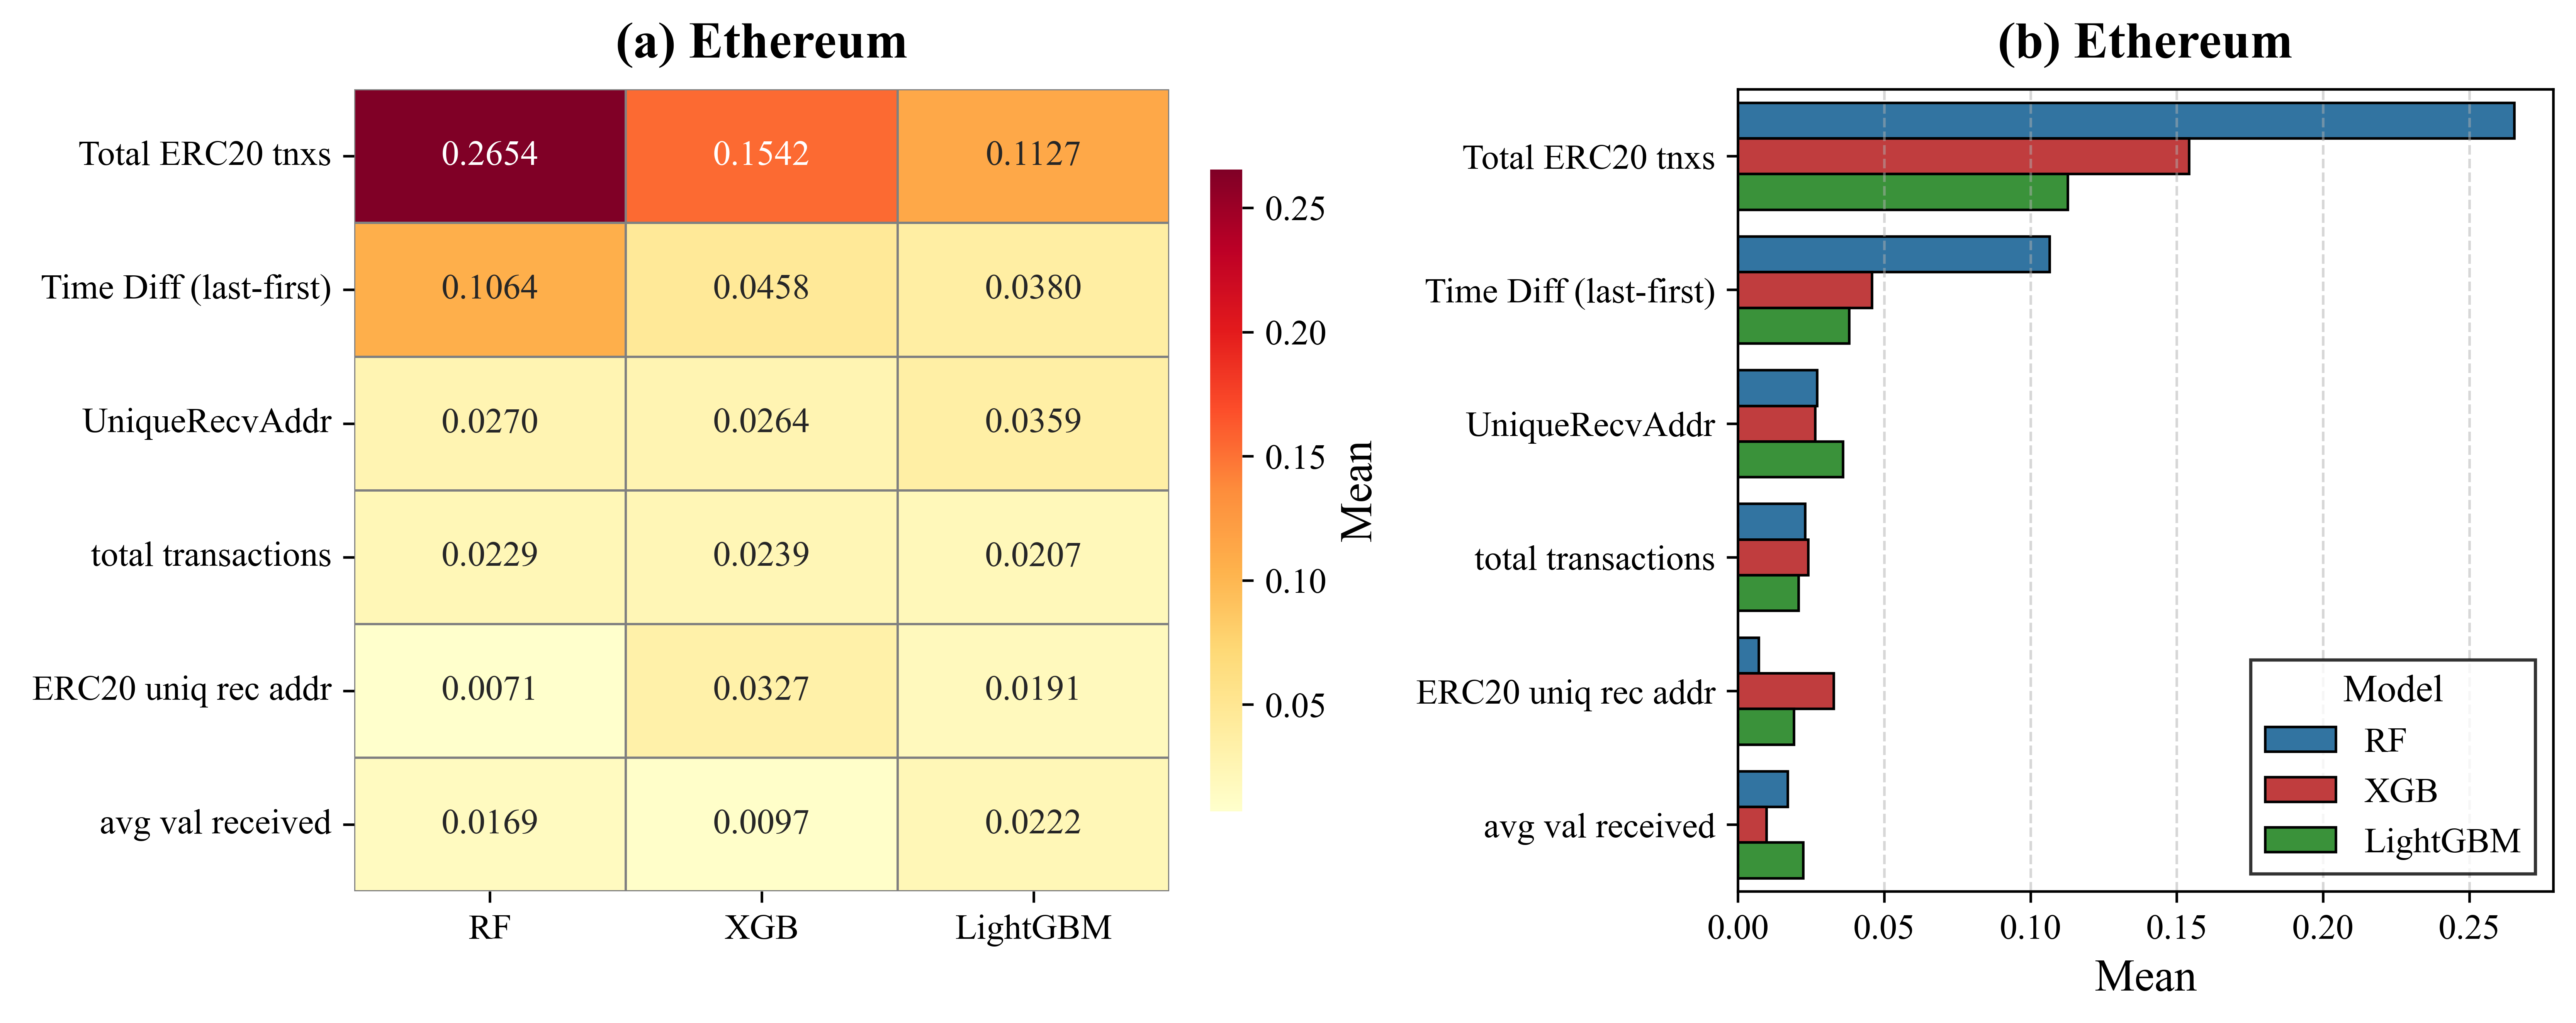

In [19]:

df_mean = pd.DataFrame(mean_abs_dict, index=feature_cols)

top_n = 6 if len(feature_cols) >= 10 else len(feature_cols)

df_mean['avg'] = df_mean.mean(axis=1)
df_mean = df_mean.sort_values('avg', ascending=False)
df_top = df_mean.head(top_n).drop(columns='avg')   


plt.close('all')
fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4.3),  
    dpi=600,
    constrained_layout=True
)
ax0, ax1 = axes

sns.heatmap(
    df_top,
    annot=True,
    fmt=".4f",             
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Mean", "shrink": 0.8},
    ax=ax0,
    annot_kws={"size": 11}
)

ax0.set_title("(a) Ethereum", pad=10, fontweight='bold')
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_yticklabels(df_top.index, rotation=0)
ax0.set_xticklabels(df_top.columns, rotation=0)


df_long = (
    df_top
    .reset_index()
    .melt(id_vars="index", var_name="Model", value_name="Importance")
    .rename(columns={"index": "Feature"})
)

feature_order = df_top.index.tolist()

sns.barplot(
    data=df_long,
    x="Importance",
    y="Feature",
    hue="Model",
    order=feature_order,
    palette=["#1f77b4", "#d62728", "#2ca02c"],  
    ax=ax1,
    edgecolor='black',
    linewidth=0.8
)

ax1.set_title("(b) Ethereum", pad=10, fontweight='bold')
ax1.set_xlabel("Mean")
ax1.set_ylabel("")
ax1.grid(axis="x", linestyle='--', alpha=0.5)

ax1.legend(
    title="Model",
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

fig.savefig("ethereum.png", dpi=600, bbox_inches="tight")

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

def _score_pos(model, X):

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1]
        return proba.ravel()
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None

def _safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if y_score is None or len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

rows = []


base_models = {"RF": best_rf, "XGB": best_xgb, "LGBM": best_lgbm}
for name, model in base_models.items():
    y_pred  = model.predict(X_test_scaled)
    y_score = _score_pos(model, X_test_scaled)

    rows.append({
        "seed": int(RANDOM_STATE),
        "model": name,
        "f1_macro": round(float(f1_score(y_test, y_pred, average="macro")), 6),
        "roc_auc":  round(float(_safe_auc(y_test, y_score)), 6) if np.isfinite(_safe_auc(y_test, y_score)) else np.nan
    })


if "results_df" in globals():
    tmp = results_df.copy()
    tmp["model"] = tmp["ensemble"].astype(str) + "_" + tmp["voting"].astype(str)

    for _, r in tmp.iterrows():
        rows.append({
            "seed": int(RANDOM_STATE),
            "model": str(r["model"]),
            "f1_macro": round(float(r.get("f1_macro", np.nan)), 6) if pd.notna(r.get("f1_macro", np.nan)) else np.nan,
            "roc_auc":  round(float(r.get("roc_auc",  np.nan)), 6) if pd.notna(r.get("roc_auc",  np.nan)) else np.nan,
        })
else:
    print("WARNING: results_df chưa tồn tại -> chỉ lưu metric cho 3 base models.")


out_csv = Path(r"D:\elliptic\Ethereum-Fraud-Detection-Dataset\runs\metrics_all_models_by_seed.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)

df_out = pd.DataFrame(rows)

write_header = (not out_csv.exists()) or out_csv.stat().st_size == 0
df_out.to_csv(out_csv, mode="a", header=write_header, index=False)

print("Saved:", out_csv, "| rows:", len(df_out))


[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Warning] Unknown parameter: eval_metric
Saved: D:\elliptic\Ethereum-Fraud-Detection-Dataset\runs\metrics_all_models_by_seed.csv | rows: 11


In [21]:
import os

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

csv_path = os.path.join(out_dir, "ensemble_results_ethereum.csv")
results_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("Saved:", csv_path)

Saved: outputs\ensemble_results_ethereum.csv
